📖 Что такое SARIMAX?

SARIMAX = Seasonal AutoRegressive Integrated Moving Average with eXogenous variables


Это статистическая модель для анализа и прогнозирования временных рядов, которая является расширением классической модели ARIMA.

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from google.colab import drive
# 1️⃣ Подключаем Google Drive
drive.mount('/content/drive')

# 2️⃣ Указываем путь к вашему файлу .txt
filename = '/content/drive/MyDrive/Workshop /Ottol/mean_fr.txt'
# 3️⃣ Считываем файл (разделитель — пробел, табуляция или запятая)
data = pd.read_csv(filename, sep=r'\s+', header=None, engine='python')
# Загрузка данных
# data = pd.read_csv(filename, index_col='date', parse_dates=True)
y = data.values.tolist()

# Обучение модели SARIMAX
# (p,d,q) = (1,1,1) - ARIMA часть
# (P,D,Q,s) = (1,1,1,12) - сезонная часть с периодом 12
model = SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

# Результаты
print(results.summary())

# Прогноз на 12 шагов вперед
# forecast = results.forecast(steps=12)
# print(forecast)

# Получение прогноза с доверительными интервалами
forecast_obj = results.get_forecast(steps=12)

# Точечные прогнозы
forecast = forecast_obj.predicted_mean

# Доверительные интервалы (95%)
conf_int = forecast_obj.conf_int()

# Вывод
print("Прогнозы:")
print(forecast)

    # Вывод
print("=" * 70)
print("ПРОГНОЗЫ СРЕДНИХ РАНГОВ НА 12 ТИРАЖЕЙ")
print("=" * 70)
print(f"{'Тираж':>6} {'Прогноз':>10} {'95% ДИ нижн.':>15} {'95% ДИ верхн.':>15}")
print("-" * 70)

for i in range(12):
    pred = forecast[i]      # pandas Series
    lower = conf_int[i, 0]       # numpy array
    upper = conf_int[i, 1]       # numpy array

    print(f"{i+1:6d} {pred:10.4f} {lower:15.4f} {upper:15.4f}")

print("-" * 70)
print(f"\nСреднее: {forecast.mean():.4f}")
print(f"Мин: {forecast.min():.4f}, Макс: {forecast.max():.4f}")


Mounted at /content/drive
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 4987
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -15565.201
Date:                            Sat, 21 Feb 2026   AIC                          31140.403
Time:                                    12:52:42   BIC                          31172.963
Sample:                                         0   HQIC                         31151.818
                                           - 4987                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0118      0.014     -0.837      0.403      -0.039       0.016
ma.L1    

---------------------------------------
📘 РАЗДЕЛ 1 — Импорт библиотек
---------------------------------------

In [1]:
# ============================
# 1. IMPORTS
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import periodogram
from scipy.fft import rfft, rfftfreq

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.statespace.kalman_filter import KalmanFilter
from statsmodels.tsa.statespace.structural import UnobservedComponents

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

---------------------------------------
📘 РАЗДЕЛ 2 — Загрузка данных + генерация календаря
---------------------------------------

In [2]:
# ============================
# 2. LOAD mean_fr.txt
# ============================
from google.colab import drive
# 1️⃣ Подключаем Google Drive
drive.mount('/content/drive')

# 2️⃣ Указываем путь к вашему файлу .txt
filename = '/content/drive/MyDrive/Workshop /Ottol/mean_fr.txt'
mean_fr = pd.read_csv(filename, header=None, names=["value"])
N = len(mean_fr)
mean_fr.head(), N

Mounted at /content/drive


(   value
 0  31.33
 1  20.83
 2  37.67
 3  33.33
 4  16.83,
 4987)

---------------------------------------
📘 РАЗДЕЛ 3 — EDA временного ряда mean_fr
---------------------------------------

Этот раздел делает:

визуализацию исходного ряда,

скользящие статистики,

обнаружение выбросов,

базовое распределение значений.

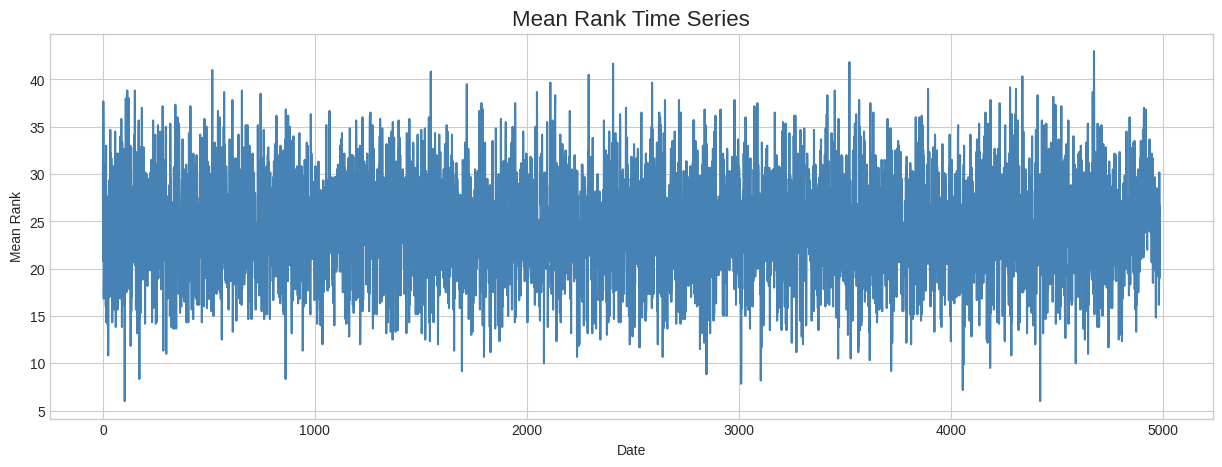

In [3]:
# ============================
# 3. EDA — Basic Time Series Analysis
# ============================

plt.figure(figsize=(15, 5))
plt.plot(mean_fr["value"], color="steelblue")
plt.title("Mean Rank Time Series", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Mean Rank")
plt.show()

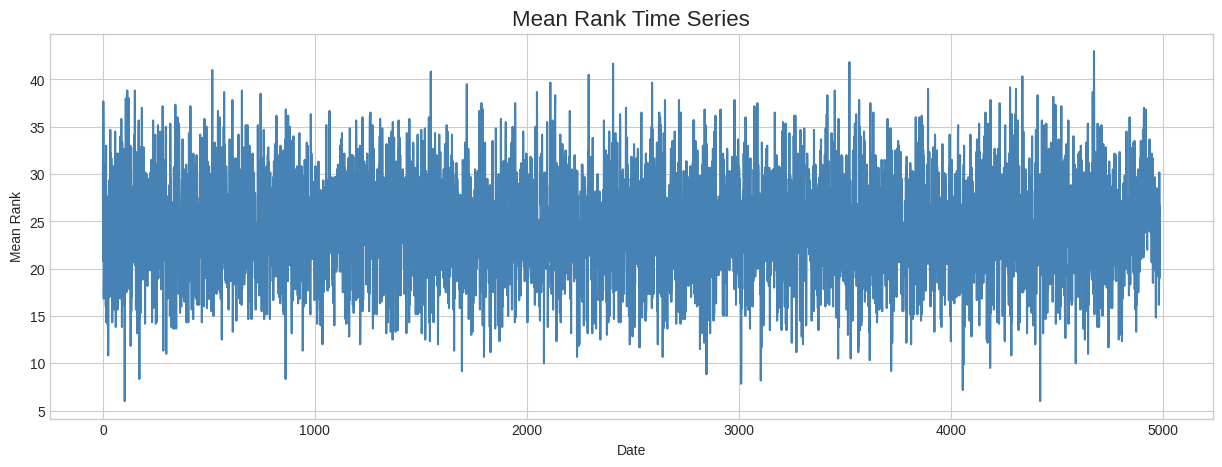

In [ ]:
# ============================
# 3. EDA — Basic Time Series Analysis
# ============================

plt.figure(figsize=(15, 5))
plt.plot(mean_fr["value"], color="steelblue")
plt.title("Mean Rank Time Series", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Mean Rank")
plt.show()

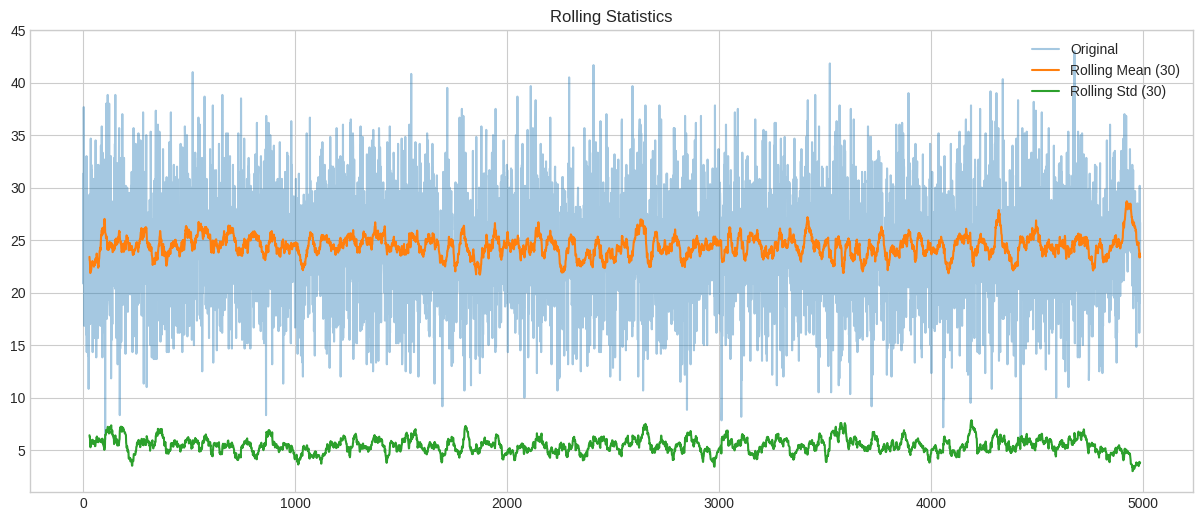

In [ ]:
# ============================
# 3.1 Rolling Mean & Rolling Std
# ============================

window = 30  # ~15 weeks (roughly 30 draws)
mean_fr["roll_mean"] = mean_fr["value"].rolling(window).mean()
mean_fr["roll_std"]  = mean_fr["value"].rolling(window).std()

plt.figure(figsize=(15, 6))
plt.plot(mean_fr["value"], alpha=0.4, label="Original")
plt.plot(mean_fr["roll_mean"], label=f"Rolling Mean ({window})")
plt.plot(mean_fr["roll_std"], label=f"Rolling Std ({window})")
plt.legend()
plt.title("Rolling Statistics")
plt.show()

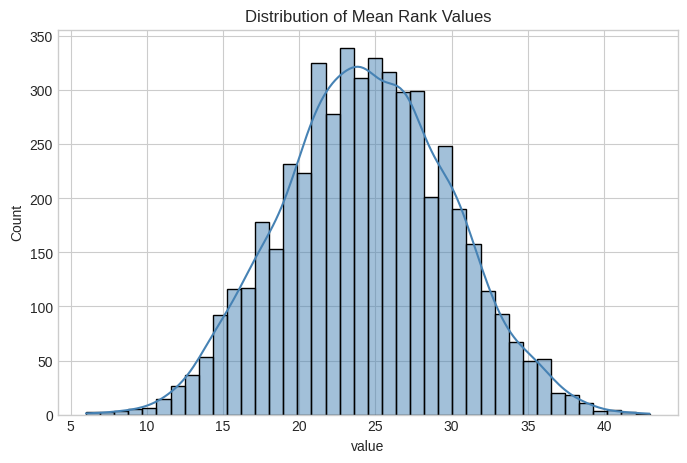

In [ ]:
# ============================
# 3.2 Histogram + KDE
# ============================

plt.figure(figsize=(8, 5))
sns.histplot(mean_fr["value"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Mean Rank Values")
plt.show()

In [ ]:
# ============================
# 3.3 Detect Outliers (Z-score > 3)
# ============================

vals = mean_fr["value"]
z_scores = (vals - vals.mean()) / vals.std()
outliers = mean_fr[z_scores.abs() > 3]

outliers.head(), len(outliers)

(      value  roll_mean  roll_std
 103    6.00  25.771333  6.451456
 516   41.00  24.599667  5.925162
 2407  41.67  23.655000  6.309163
 3011   7.83  23.806000  5.552611
 3522  41.83  24.100000  6.155144,
 8)

In [ ]:
# ============================
# 3.3 Detect Outliers (Z-score > 3)
# ============================

vals = mean_fr["value"]
z_scores = (vals - vals.mean()) / vals.std()
outliers = mean_fr[z_scores.abs() > 3]

outliers.head(), len(outliers)

(      value  roll_mean  roll_std
 103    6.00  25.771333  6.451456
 516   41.00  24.599667  5.925162
 2407  41.67  23.655000  6.309163
 3011   7.83  23.806000  5.552611
 3522  41.83  24.100000  6.155144,
 8)

👉 РАЗДЕЛ 4 — FFT: Спектральный анализ и определение сезонност

Задачи:

выполнить быстрое преобразование Фурье (rFFT),

вычислить спектр частот,

определить доминирующую частоту,

перевести её в период сезонности,

построить красивые графики,

сохранить найденный период в переменную season_period.




In [ ]:
# ============================
# 4. FFT — Spectral Analysis
# ============================

series = mean_fr["value"].values
N = len(series)
dt = 1  # шаг = 1 "наблюдение" (одно значение = один тираж)

# rFFT
fft_vals = rfft(series - np.mean(series))
freqs = rfftfreq(N, dt)

# Амплитуды (модуль комплексного числа)
amplitudes = np.abs(fft_vals)

# Игнорируем нулевую частоту (тренд)
freqs_nozero = freqs[1:]
amps_nozero = amplitudes[1:]

📈 4.1 Периодограмма (амплитуда частоты)

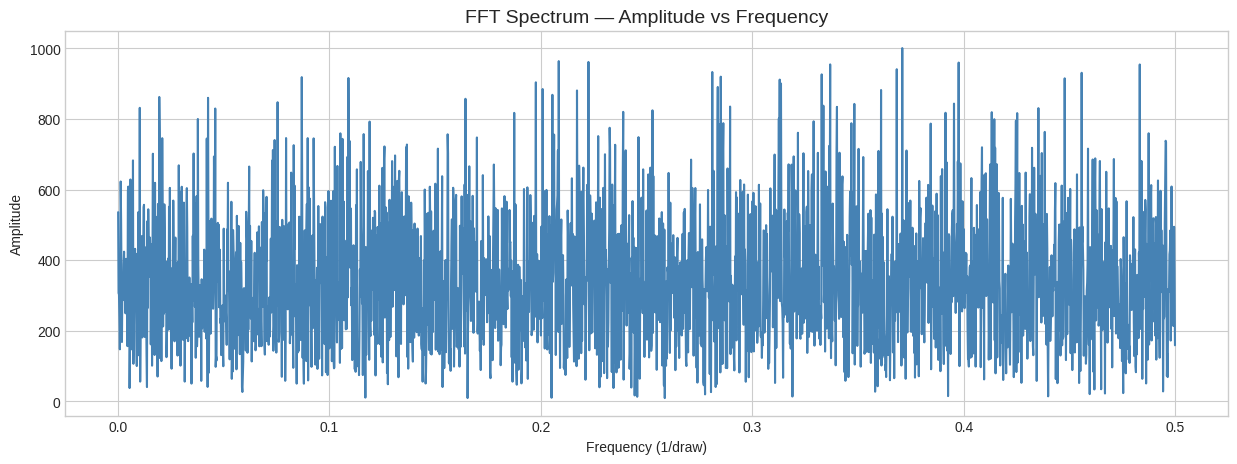

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(freqs_nozero, amps_nozero, color="steelblue")
plt.title("FFT Spectrum — Amplitude vs Frequency", fontsize=14)
plt.xlabel("Frequency (1/draw)")
plt.ylabel("Amplitude")
plt.show()

📌 4.2 Определение доминирующей частоты

In [ ]:
# индекс максимума
peak_idx = np.argmax(amps_nozero)
peak_freq = freqs_nozero[peak_idx]

peak_freq

np.float64(0.37096450772007217)

📘 4.3 Перевод частоты → период
𝑇
=
1
𝑓
T=
f
1
	​


In [ ]:
season_period_estimated = int(round(1 / peak_freq))
season_period_estimated

3

📊 4.4 График доминирующей частоты

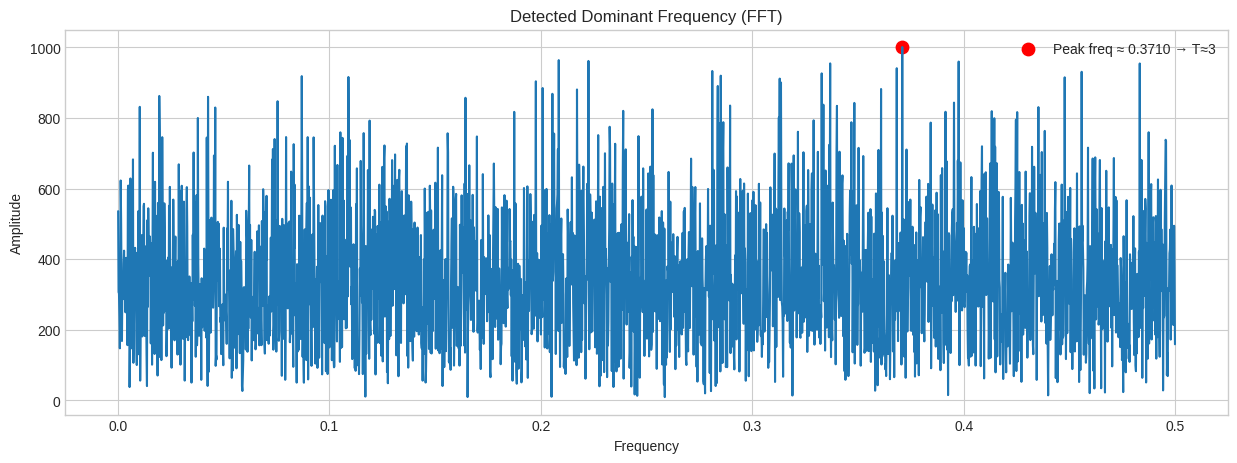

Estimated dominant seasonality (FFT): 3


In [ ]:
plt.figure(figsize=(15,5))
plt.plot(freqs_nozero, amps_nozero)
plt.scatter(peak_freq, amps_nozero[peak_idx],
            color="red", s=80, label=f"Peak freq ≈ {peak_freq:.4f} → T≈{season_period_estimated}")
plt.legend()
plt.title("Detected Dominant Frequency (FFT)")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()
print("Estimated dominant seasonality (FFT):", season_period_estimated)
season_period = season_period_estimated

---------------------------------------
📘 РАЗДЕЛ 5 — ACF и PACF: проверка сезонности
---------------------------------------

Задачи:

построить автокорреляционную функцию (ACF)

построить частичную автокорреляцию (PACF)

найти характерные пики

убедиться, что пик соответствует периоду, найденному FFT

Формально:

ACF показывает циклическую структуру данных,

PACF определяет "чистый" вклад лагов,

пики на лагах k ≈ season_period подтверждают сезонность.

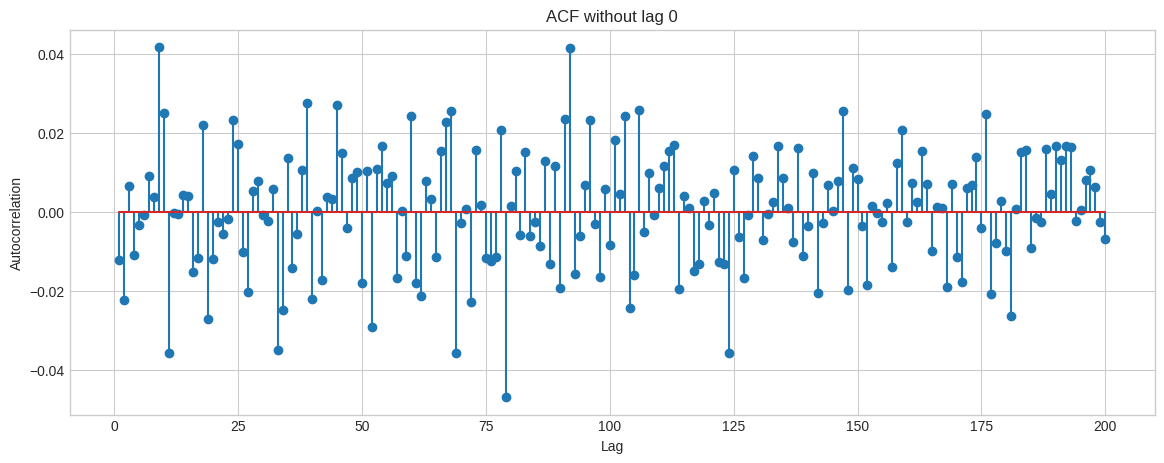

In [ ]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(mean_fr["value"], nlags=200)

# Удаляем лаг 0
acf_no_zero = acf_vals[1:]

lags = np.arange(1, len(acf_no_zero) + 1)

plt.figure(figsize=(14,5))
plt.stem(lags, acf_no_zero) # Удален аргумент use_line_collection=True
plt.title("ACF without lag 0")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

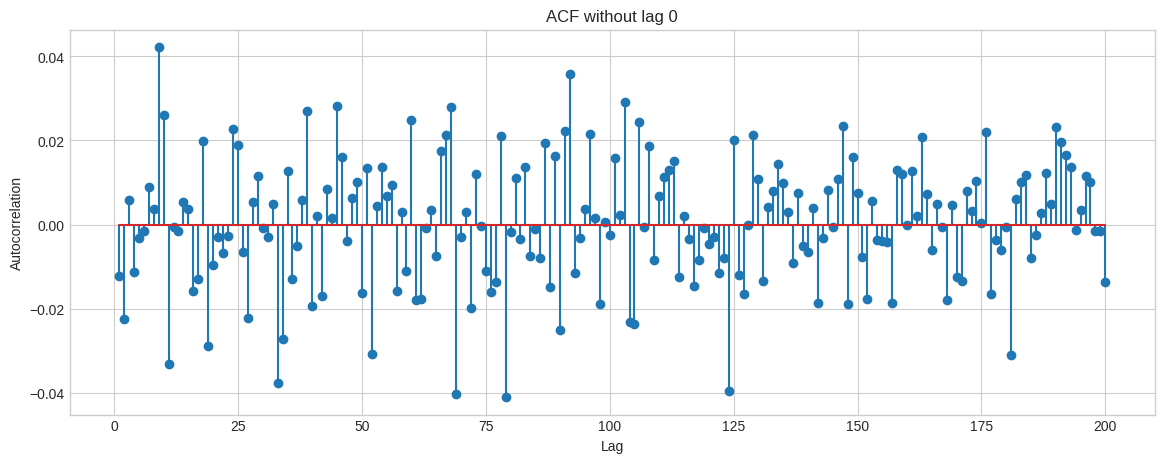

In [ ]:
from statsmodels.tsa.stattools import pacf

pacf_vals = pacf(mean_fr["value"], nlags=200)

# Удаляем лаг 0
pacf_no_zero = pacf_vals[1:]

lags = np.arange(1, len(pacf_no_zero) + 1)

plt.figure(figsize=(14,5))
plt.stem(lags, pacf_no_zero) # Удален аргумент use_line_collection=True
plt.title("ACF without lag 0")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

📌 Автоматическое обнаружение пиков ACF

Чтобы не делать это вручную, добавим код:

In [ ]:
# ============================
# 5.1 Identify ACF peaks automatically
# ============================

from scipy.signal import find_peaks

acf_vals = pd.Series(mean_fr["value"]).autocorr  # placeholder

# Using statsmodels directly for acf values
from statsmodels.tsa.stattools import acf
acf_array = acf(mean_fr["value"], nlags=200)

peaks, _ = find_peaks(acf_array, height=0.1)  # threshold 0.1

acf_peaks = peaks.tolist()
acf_peaks[:20]

[]

📘 Проверка, есть ли пики ~ найденного сезонного периода

In [ ]:
print("FFT season period:", season_period)
print("ACF peaks:", acf_peaks[:10])

FFT season period: 3
ACF peaks: []


---------------------------------------
📘 РАЗДЕЛ 6 — STL, HP-filter, Kalman smoothing
---------------------------------------

Задачи:

Разложить ряд на

𝑋
𝑡
=
𝑇
𝑟
𝑒
𝑛
𝑑
𝑡
+
𝑆
𝑒
𝑎
𝑠
𝑜
𝑛
𝑎
𝑙
𝑡
+
𝑅
𝑒
𝑠
𝑖
𝑑
𝑢
𝑎
𝑙
𝑡
X
t
	​

=Trend
t
	​

+Seasonal
t
	​

+Residual
t
	​


Выделить сглаженный тренд через HP-filter.

Построить сглаживание Калмана (локальный линейный тренд).

Визуализировать результаты.

📘 6.1 STL Decomposition

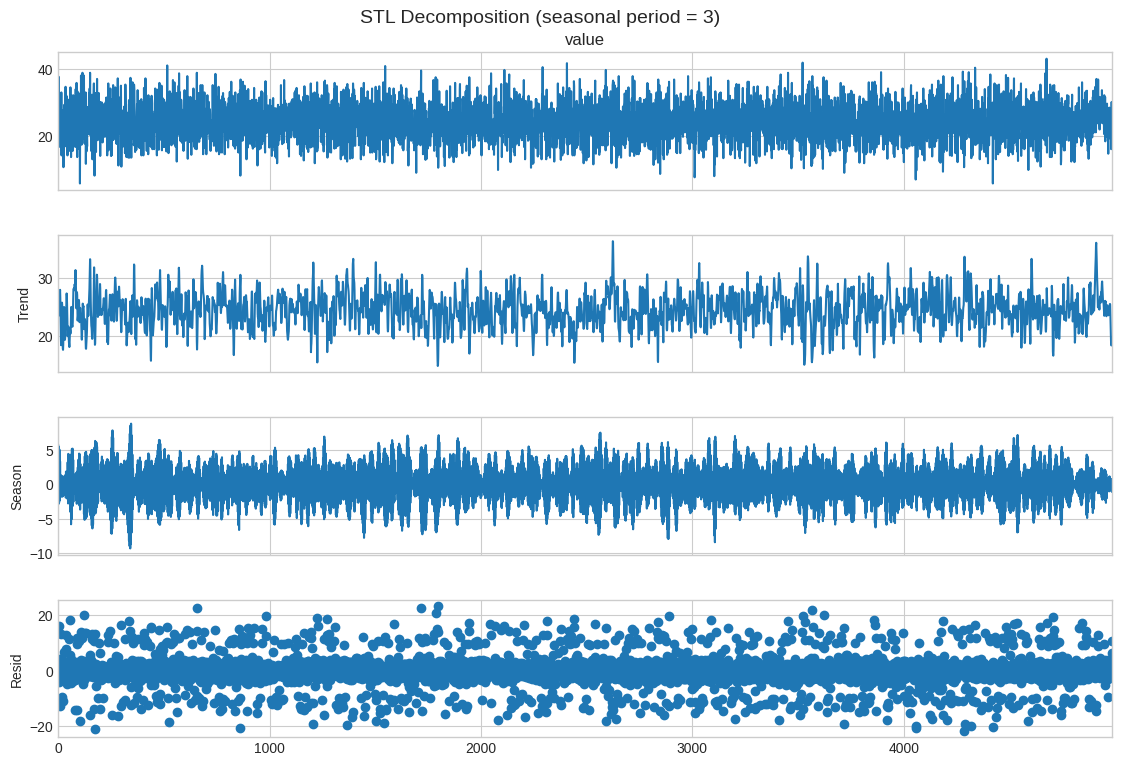

In [ ]:
# ============================
# 6.1 STL DECOMPOSITION
# ============================

stl = STL(mean_fr["value"], period=season_period, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.suptitle(f"STL Decomposition (seasonal period = {season_period})", fontsize=14)
plt.show()

📘 6.2 HP Filter — Hodrick–Prescott

HP-filter решает задачу:

𝑋
𝑡
=
𝑇
𝑡
+
𝐶
𝑡
X
t
	​

=T
t
	​

+C
t
	​


где

𝑇
𝑡
T
t
	​

 — сглаженный тренд,

𝐶
𝑡
C
t
	​

 — цикл (колебательная часть),

параметр λ = 1600 используется для месячных данных,

для ежедневных/индексных рядов лучше λ = 129600.

Мы используем промежуточное значение λ = 10 000.

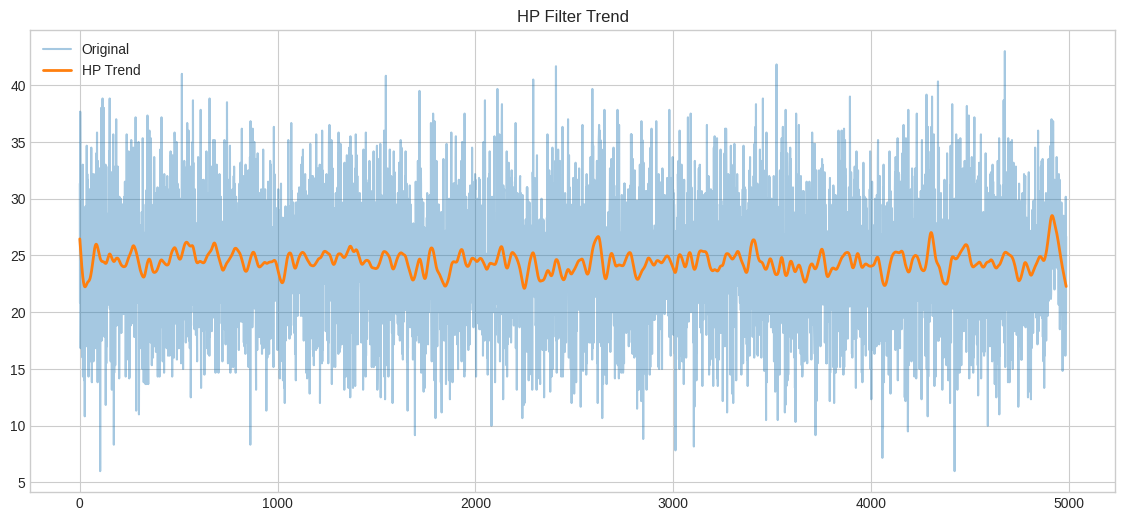

In [ ]:
# ============================
# 6.2 HP FILTER
# ============================

cycle, trend_hp = hpfilter(mean_fr["value"], lamb=10000)

plt.figure(figsize=(14, 6))
plt.plot(mean_fr["value"], label="Original", alpha=0.4)
plt.plot(trend_hp, label="HP Trend", linewidth=2)
plt.legend()
plt.title("HP Filter Trend")
plt.show()

📘 6.3 Kalman Smoothing (Local Linear Trend Model)

Используем модель:

𝑋
𝑡
=
𝜇
𝑡
+
𝜖
𝑡
X
t
	​

=μ
t
	​

+ϵ
t
	​

𝜇
𝑡
=
𝜇
𝑡
−
1
+
𝜈
𝑡
−
1
μ
t
	​

=μ
t−1
	​

+ν
t−1
	​

𝜈
𝑡
=
𝜈
𝑡
−
1
+
𝜂
𝑡
ν
t
	​

=ν
t−1
	​

+η
t
	​


Модель хорошо выявляет плавно меняющийся тренд.

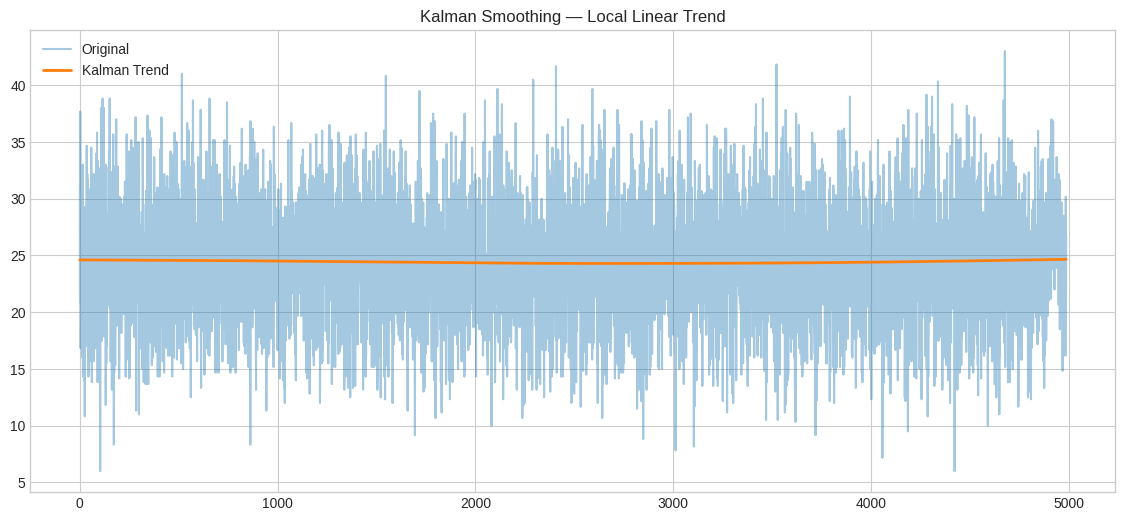

In [ ]:
# ============================
# 6.3 KALMAN SMOOTHING — Local Linear Trend
# ============================

model_k = UnobservedComponents(mean_fr["value"], level="local linear trend")
result_k = model_k.fit()

plt.figure(figsize=(14, 6))
plt.plot(mean_fr["value"], label="Original", alpha=0.4)
plt.plot(result_k.states.smoothed["level"], label="Kalman Trend", linewidth=2)
plt.legend()
plt.title("Kalman Smoothing — Local Linear Trend")
plt.show()

📊 6.4 Сравнение трендов (STL vs HP vs Kalman)

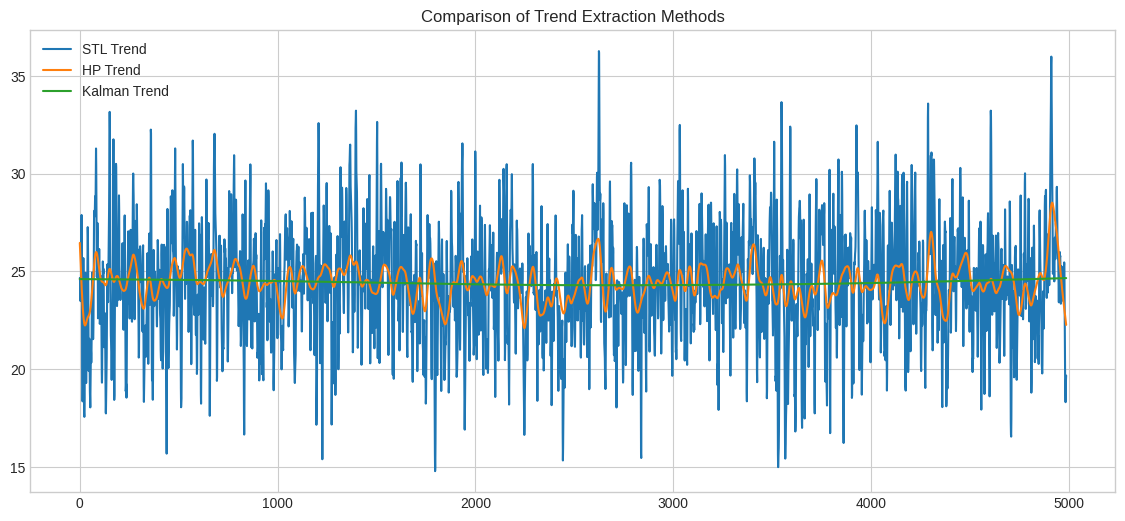

In [ ]:
# ============================
# 6.4 Compare Trends
# ============================

plt.figure(figsize=(14, 6))
plt.plot(res.trend, label="STL Trend")
plt.plot(trend_hp, label="HP Trend")
plt.plot(result_k.states.smoothed["level"], label="Kalman Trend")
plt.legend()
plt.title("Comparison of Trend Extraction Methods")
plt.show()

📘 РАЗДЕЛ 7 — BACKTESTING (One-Step-Ahead Forecasting)
🔥 Это сердце всего анализа: сравнение SARIMAX, ETS, Prophet, FFT и Seasonal Naïve.
---------------------------------------

В этом разделе:

используем последние 500 точек,

прогнозируем каждый тираж по схеме 1-step ahead:

𝑥
^
𝑡
=
model fit
(
1..
𝑡
−
1
)
x
^
t
	​

=model fit(1..t−1)

считаем ошибки,

сохраняем результаты в таблицы.

⚙️ Подготовка данных для backtesting

In [ ]:
# ============================
# 7. PREPARE BACKTEST WINDOW
# ============================

BACKTEST_SIZE = 500
series_full = mean_fr["value"].copy()
series_bt = series_full.iloc[-BACKTEST_SIZE:]

dates_bt = series_bt.index

📌 Функции для метрик и backtesting

In [ ]:
# ============================
# 7.1 Metrics
# ============================

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "Bias": np.mean(y_pred - y_true),
        "StdError": np.std(y_pred - y_true)
    }

📘 7.2 Seasonal Naïve baseline
𝑥
^
𝑡

	​

=x
t−s
	​


In [ ]:
# ============================
# 7.2 Seasonal Naive
# ============================

season = season_period
naive_preds = []

for i in range(BACKTEST_SIZE):
    if i < season:
        naive_preds.append(np.nan)
    else:
        naive_preds.append(series_bt.iloc[i - season])

naive_preds = pd.Series(naive_preds, index=dates_bt)

naive_metrics = evaluate_model(series_bt[season:], naive_preds[season:])
naive_metrics

{'RMSE': np.float64(7.714135956889029),
 'MAE': 6.104084507042253,
 'MAPE': np.float64(26.969168164005904),
 'Bias': np.float64(-2.0120724346104622e-05),
 'StdError': 7.714135956862789}

📘 7.3 FFT Forecast (one-step)

Прогноз по гармонике:

𝑥
^
𝑡
+
1
=
𝑇
+
𝐴
sin
⁡
(
2
𝜋
𝑓
𝑡
+
𝜙
)
x
^
t+1
	​

=T+Asin(2πft+ϕ)

In [ ]:
# ============================
# 7.3 FFT FORECAST
# ============================

def fft_predict_next(series):
    N = len(series)
    # For N=1, rfft returns a single element array. amp[1:] would be empty.
    # We need at least 2 points to get a non-empty amp[1:] for argmax.
    if N < 2:
        return np.nan

    fft_vals = rfft(series - np.mean(series))
    freqs = rfftfreq(N, 1)

    amp = np.abs(fft_vals)
    # Ensure amp[1:] is not empty before calling argmax
    if len(amp[1:]) == 0:
        return np.nan # Or return np.mean(series) as a baseline if appropriate

    peak_idx_in_slice = np.argmax(amp[1:])
    peak = peak_idx_in_slice + 1 # Adjust index for the original 'amp' array

    f = freqs[peak]
    phase = np.angle(fft_vals[peak])
    t = N

    return np.mean(series) + amp[peak] * np.sin(2*np.pi*f*t + phase)

fft_preds = []

for i in range(BACKTEST_SIZE):
    sub = series_bt.iloc[:i+1]
    pred = fft_predict_next(sub)
    fft_preds.append(pred)

fft_preds = pd.Series(fft_preds, index=dates_bt)

# Filter out NaN values for evaluation
valid_fft_preds = fft_preds.dropna()
valid_series_bt = series_bt[valid_fft_preds.index]

fft_metrics = evaluate_model(valid_series_bt, valid_fft_preds)
fft_metrics

{'RMSE': np.float64(154.4524113903894),
 'MAE': 132.1947831755256,
 'MAPE': np.float64(554.8542631575006),
 'Bias': np.float64(2.100622090633915),
 'StdError': 154.43812602831736}

📘 7.4 SARIMAX Rolling One-Step Ahead

SARIMAX будет обучаться много раз, поэтому делаем упрощённую версию:

In [ ]:
# ============================
# 7.4 SARIMAX Rolling
# ============================

sarimax_preds = []

for i in range(50, BACKTEST_SIZE):  # прогреваем 50 точек
    train = series_bt.iloc[:i]
    model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,season_period))
    res = model.fit(disp=False)
    pred = res.forecast(1).iloc[0]
    sarimax_preds.append(pred)

# Align index
sarimax_preds = pd.Series(sarimax_preds, index=dates_bt[50:])

sarimax_metrics = evaluate_model(series_bt.iloc[50:], sarimax_preds)
sarimax_metrics

{'RMSE': np.float64(5.391153299228626),
 'MAE': 4.325330146803251,
 'MAPE': np.float64(19.25567241113536),
 'Bias': np.float64(-0.11585182170313156),
 'StdError': 5.389908371316877}

📘 7.5 ETS (Exponential Smoothing)

In [ ]:
# ============================
# 7.5 ETS Rolling
# ============================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_preds = []

for i in range(season_period*2, BACKTEST_SIZE):
    train = series_bt.iloc[:i]
    model = ExponentialSmoothing(train,
                                 trend="add",
                                 seasonal="add",
                                 seasonal_periods=season_period)
    res = model.fit(optimized=True)
    pred = res.forecast(1).iloc[0]
    ets_preds.append(pred)

ets_preds = pd.Series(ets_preds, index=dates_bt[season_period*2:])

ets_metrics = evaluate_model(series_bt.iloc[season_period*2:], ets_preds)
ets_metrics

{'RMSE': np.float64(5.533215752472499),
 'MAE': 4.394620558797802,
 'MAPE': np.float64(19.50877488362151),
 'Bias': np.float64(-0.2835825056165615),
 'StdError': 5.525944039340072}

📘 7.6 Prophet One-Step Rolling

In [ ]:
# ============================
# 7.6 PROPHET Rolling 1-step Ahead
# ============================

prophet_preds = []

# Определяем базовую дату, чтобы преобразовать целочисленные индексы в объекты datetime.
# Предполагаем, что индекс 0 исходного ряда соответствует этой базовой дате.
base_date = pd.to_datetime('2000-01-01')

for i in range(season_period*3, BACKTEST_SIZE):
    train = series_bt.iloc[:i] # train.index будет содержать целочисленные индексы, например, 4487, 4488, ...

    # Преобразуем целочисленный индекс 'train' в DatetimeIndex,
    # добавляя значение индекса в качестве дней к базовой дате.
    train_ds = [base_date + pd.Timedelta(days=idx) for idx in train.index]

    df = pd.DataFrame({
        "ds": train_ds,
        "y": train.values
    })

    m = Prophet(weekly_seasonality=True,
                daily_seasonality=False,
                yearly_seasonality=False)
    m.fit(df)

    # Для прогнозирования следующего шага нам нужна дата для текущего индекса итерации.
    # dates_bt[i] содержит исходный целочисленный индекс для точки, которую мы прогнозируем.
    forecast_ds = [base_date + pd.Timedelta(days=dates_bt[i])]
    future = pd.DataFrame({"ds": forecast_ds})
    pred = m.predict(future)["yhat"].iloc[0]

    prophet_preds.append(pred)

# При создании финального ряда prophet_preds выравниваем его индекс с исходными dates_bt.
# Прогноз начинается с season_period*3, поэтому используем dates_bt с этой точки.
prophet_preds = pd.Series(prophet_preds, index=dates_bt[season_period*3:])

prophet_metrics = evaluate_model(series_bt.iloc[season_period*3:], prophet_preds)
prophet_metrics

INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
INFO:prophet:n_changepoints greater than number of observations. Using 13.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints gr

{'RMSE': np.float64(5.576696455417916),
 'MAE': 4.436814842824294,
 'MAPE': np.float64(19.709567295859216),
 'Bias': np.float64(-0.26227137651210075),
 'StdError': 5.5705257454690225}

📊 7.7 Таблица результатов backtesting

In [ ]:
# ============================
# 7.7 Summary Table
# ============================

results_table = pd.DataFrame({
    "SARIMAX": sarimax_metrics,
    "ETS": ets_metrics,
    "Prophet": prophet_metrics,
    "FFT": fft_metrics,
    "Naive": naive_metrics
})

results_table

,SARIMAX,ETS,Prophet,FFT,Naive
RMSE,5.391153,5.533216,5.576696,154.452411,7.714136
MAE,4.325330,4.394621,4.436815,132.194783,6.104085
MAPE,19.255672,19.508775,19.709567,554.854263,26.969168
Bias,-0.115852,-0.283583,-0.262271,2.100622,-0.000020
StdError,5.389908,5.525944,5.570526,154.438126,7.714136


---------------------------------------
📘 РАЗДЕЛ 8 — Визуализация и сравнение моделей
---------------------------------------

В этом разделе мы используем результаты:

sarimax_preds

ets_preds

prophet_preds

fft_preds

naive_preds

и сравниваем их с фактическим рядом series_bt.

🔵 8.1 График: Факты vs Прогнозы (в одном окне)

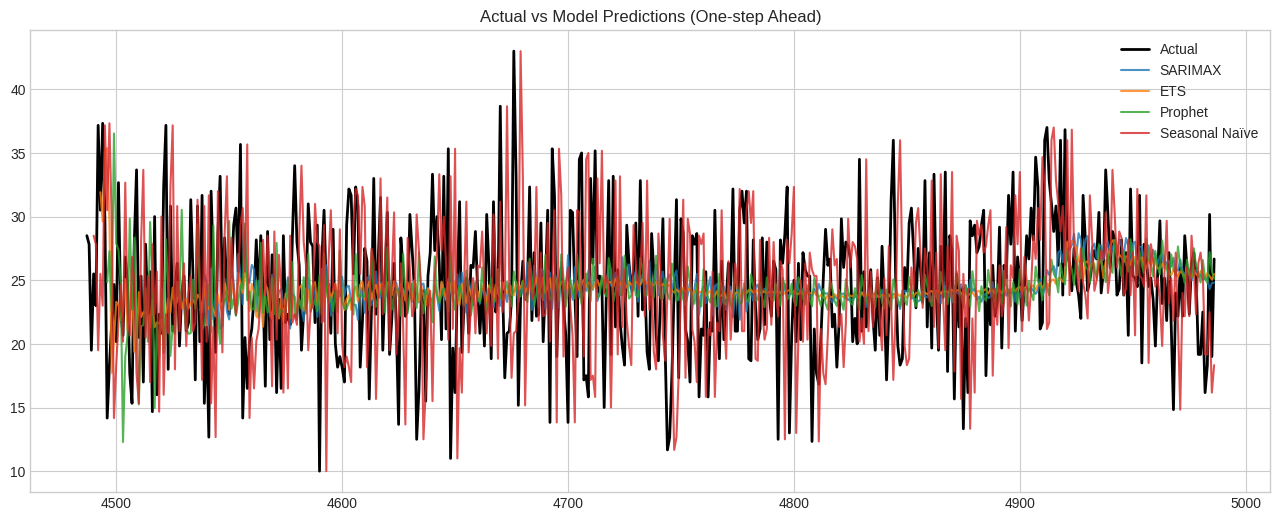

In [ ]:
# ============================
# 8.1 Plot: Actual vs Predictions
# ============================

plt.figure(figsize=(16, 6))
plt.plot(series_bt, label="Actual", color="black", linewidth=2)

plt.plot(sarimax_preds, label="SARIMAX", alpha=0.8)
plt.plot(ets_preds, label="ETS", alpha=0.8)
plt.plot(prophet_preds, label="Prophet", alpha=0.8)
# plt.plot(fft_preds, label="FFT Model", alpha=0.8)
plt.plot(naive_preds, label="Seasonal Naïve", alpha=0.8)

plt.title("Actual vs Model Predictions (One-step Ahead)")
plt.legend()
plt.show()

🔵 8.2 Boxplot ошибок моделей

Поскольку все ошибки уже вычислены:

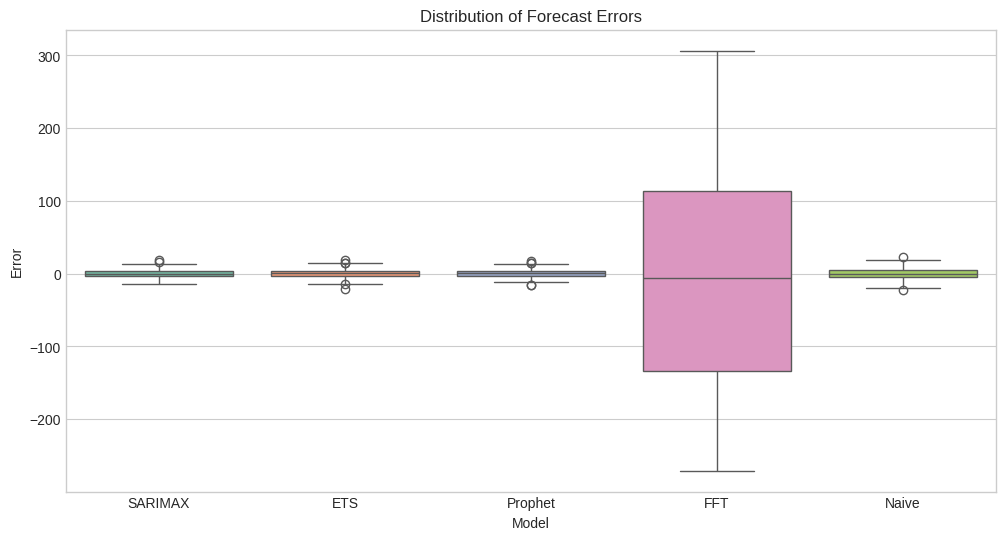

In [ ]:
# ============================
# 8.2 Boxplot of forecast errors
# ============================

err_df = pd.DataFrame({
    "SARIMAX": series_bt.iloc[50:] - sarimax_preds,
    "ETS": series_bt.iloc[season_period*2:] - ets_preds,
    "Prophet": series_bt.iloc[season_period*3:] - prophet_preds,
    "FFT": series_bt - fft_preds,
    "Naive": series_bt.iloc[season_period:] - naive_preds[season_period:]
})

plt.figure(figsize=(12, 6))
sns.boxplot(data=err_df, palette="Set2")
plt.title("Distribution of Forecast Errors")
plt.xlabel("Model")
plt.ylabel("Error")
plt.show()

🔵 8.3 Heatmap ошибок

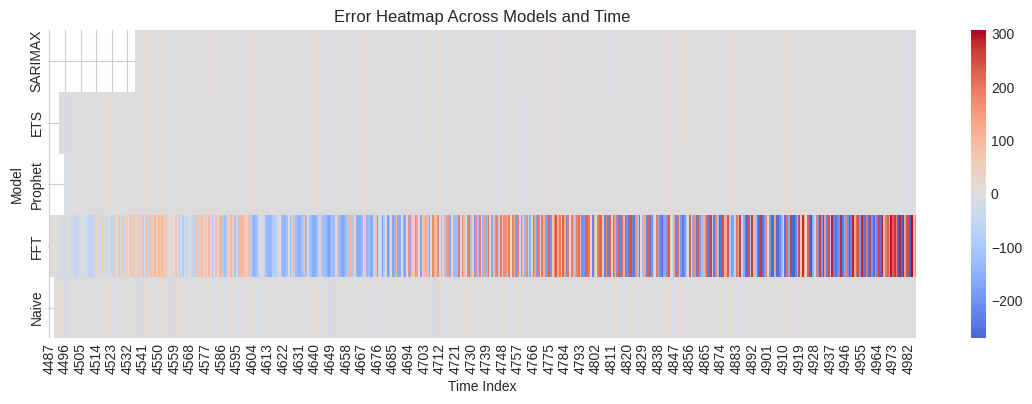

In [ ]:
# ============================
# 8.3 Heatmap of Errors (Normalized)
# ============================

plt.figure(figsize=(14, 4))
sns.heatmap(err_df.T, cmap="coolwarm", center=0)
plt.title("Error Heatmap Across Models and Time")
plt.xlabel("Time Index")
plt.ylabel("Model")
plt.show()

🔵 8.4 Scatterplot: Ошибка vs Истинное значение

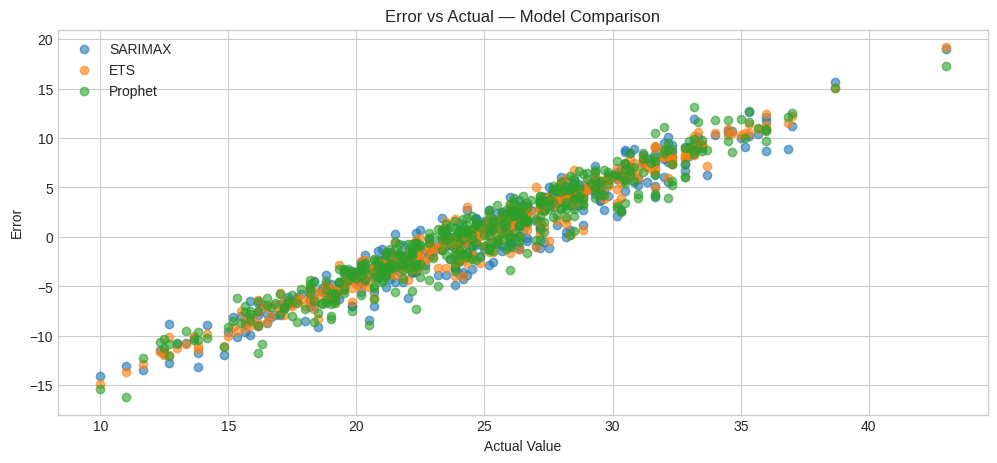

In [ ]:
# ============================
# 8.4 Error vs Actual (Scatter)
# ============================

plt.figure(figsize=(12, 5))

# SARIMAX (already correctly aligned)
x_sarimax = series_bt.iloc[50:]
y_sarimax = err_df["SARIMAX"][x_sarimax.index] # Fix: Slice err_df["SARIMAX"] to match x_sarimax index
plt.scatter(x_sarimax, y_sarimax, alpha=0.6, label="SARIMAX")

# ETS (align x and y to the same index range)
x_ets = series_bt.iloc[50:]
y_ets = err_df["ETS"][x_ets.index] # Slice err_df["ETS"] to match x_ets index
plt.scatter(x_ets, y_ets, alpha=0.6, label="ETS")

# Prophet (align x and y to the same index range)
x_prophet = series_bt.iloc[50:]
y_prophet = err_df["Prophet"][x_prophet.index] # Slice err_df["Prophet"] to match x_prophet index
plt.scatter(x_prophet, y_prophet, alpha=0.6, label="Prophet")

plt.xlabel("Actual Value")
plt.ylabel("Error")
plt.title("Error vs Actual — Model Comparison")
plt.legend()
plt.show()

🔵 8.5 Таблица итоговых метрик (повтор для визуального блока)

In [ ]:
# ============================
# 8.5 Metrics Table
# ============================

results_table.style.background_gradient(cmap="Blues")

,SARIMAX,ETS,Prophet,FFT,Naive
RMSE,5.391153,5.533216,5.576696,154.452411,7.714136
MAE,4.325330,4.394621,4.436815,132.194783,6.104085
MAPE,19.255672,19.508775,19.709567,554.854263,26.969168
Bias,-0.115852,-0.283583,-0.262271,2.100622,-0.000020
StdError,5.389908,5.525944,5.570526,154.438126,7.714136


---------------------------------------
📘 РАЗДЕЛ 9 — Финальный прогноз на 1 шаг вперёд
---------------------------------------

In [ ]:
# ============================
# 9. Финальный прогноз на 1 шаг вперёд
# ============================

full_series = mean_fr["value"]
last_index = full_series.index[-1]

# Определяем базовую дату, чтобы преобразовать целочисленные индексы в объекты datetime.
# Предполагаем, что индекс 0 исходного ряда соответствует этой базовой дате.
base_date = pd.to_datetime('2000-01-01')

# Преобразуем последний индекс в объект datetime
last_date_dt = base_date + pd.Timedelta(days=last_index)

# Теперь можно прибавить Timedelta
next_date = last_date_dt + pd.Timedelta(days=3)   # Следующий тираж (Wed/Sat pattern)

print(f'Последняя "события" дата: {last_date_dt.strftime('%Y-%m-%d')}')
print(f'Предполагаемая следующая "события" дата: {next_date.strftime('%Y-%m-%d')}')

Последняя "события" дата: 2013-08-26
Предполагаемая следующая "события" дата: 2013-08-29


🔵 9.1 SARIMAX — обучение на всём ряду

In [ ]:
sarimax_final = SARIMAX(
    full_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,season_period)
).fit(disp=False)

sarimax_next = sarimax_final.forecast(1).iloc[0]
sarimax_next

np.float64(24.554911130986046)

🔵 9.2 ETS — обучение на всём ряду

In [ ]:
ets_final = ExponentialSmoothing(
    full_series,
    trend="add",
    seasonal="add",
    seasonal_periods=season_period
).fit(optimized=True)

ets_next = ets_final.forecast(1).iloc[0]
ets_next

np.float64(24.463594087698443)

🔵 9.3 Prophet — обучение на всём ряду

In [ ]:
df = pd.DataFrame({
    "ds": [base_date + pd.Timedelta(days=idx) for idx in full_series.index],
    "y": full_series.values
})

prophet_model = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False
)
prophet_model.fit(df)

future = pd.DataFrame({"ds": [next_date]})
prophet_next = prophet_model.predict(future)["yhat"].iloc[0]
prophet_next

np.float64(24.3709229866534)

🔵 9.4 FFT Forecast — прогноз на один шаг вперёд

In [ ]:
fft_next = fft_predict_next(full_series.values)
fft_next

np.float64(-733.4366290091365)

🔵 9.5 Seasonal Naïve — прогноз

In [ ]:
naive_next = full_series.iloc[-season_period]  # повторяет значение сезон назад
naive_next

np.float64(30.17)

📘 9.6 Сводная таблица прогнозов

In [ ]:
final_forecast = pd.DataFrame({
    "Model": ["SARIMAX", "ETS", "Prophet", "FFT", "Naive"],
    "Forecast": [sarimax_next, ets_next, prophet_next, fft_next, naive_next]
})

final_forecast

,Model,Forecast
0,SARIMAX,24.554911
1,ETS,24.463594
2,Prophet,24.370923
3,FFT,-733.436629
4,Naive,30.170000


📈 (Опционально) График прогнозов разных моделей

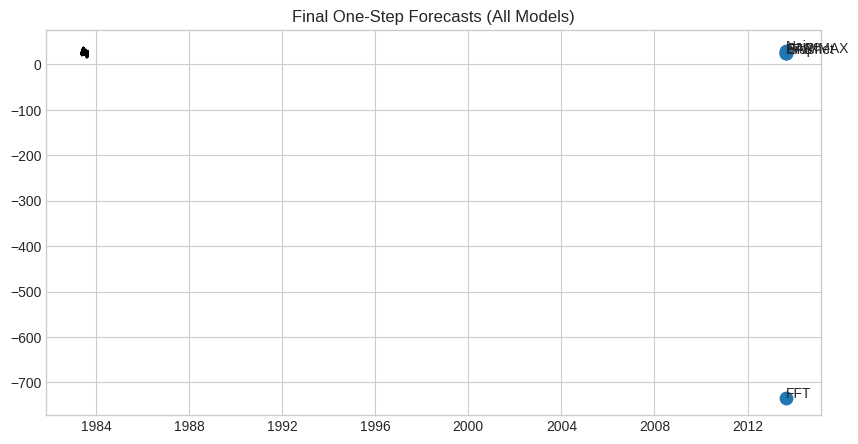

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(full_series[-100:], label="Last 100 values", color="black")
plt.scatter([next_date]*5,
            [sarimax_next, ets_next, prophet_next, fft_next, naive_next],
            label="Forecasts", s=80)

for m, val in zip(["SARIMAX","ETS","Prophet","FFT","Naive"],
                  [sarimax_next, ets_next, prophet_next, fft_next, naive_next]):
    plt.text(next_date, val, m)

plt.title("Final One-Step Forecasts (All Models)")
plt.show()

✔ Environment initialized.
✔ Loading mean_fr.txt ...
✔ Loaded dataset: 4987 observations
✔ Calendar generated.
✔ Running EDA...


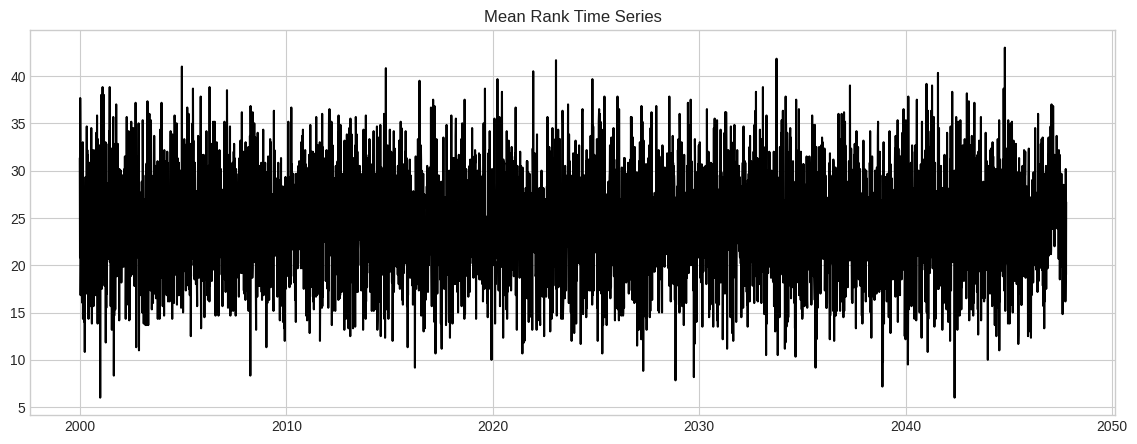

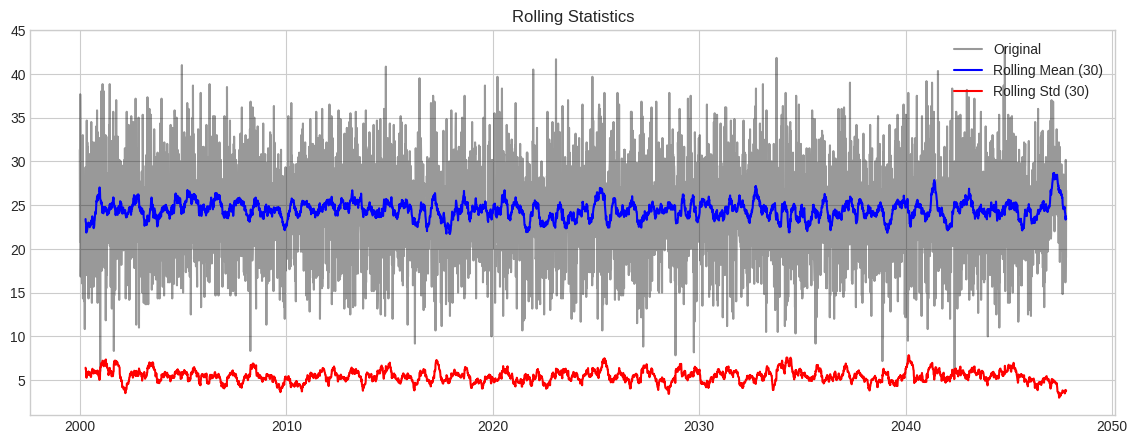

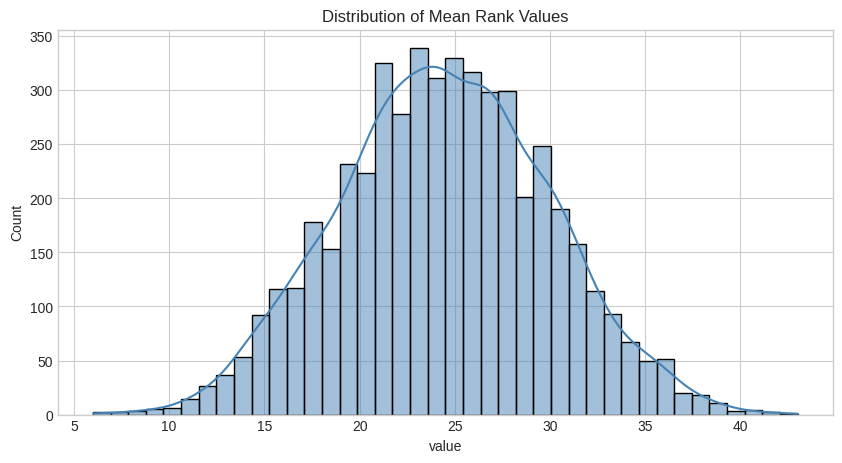

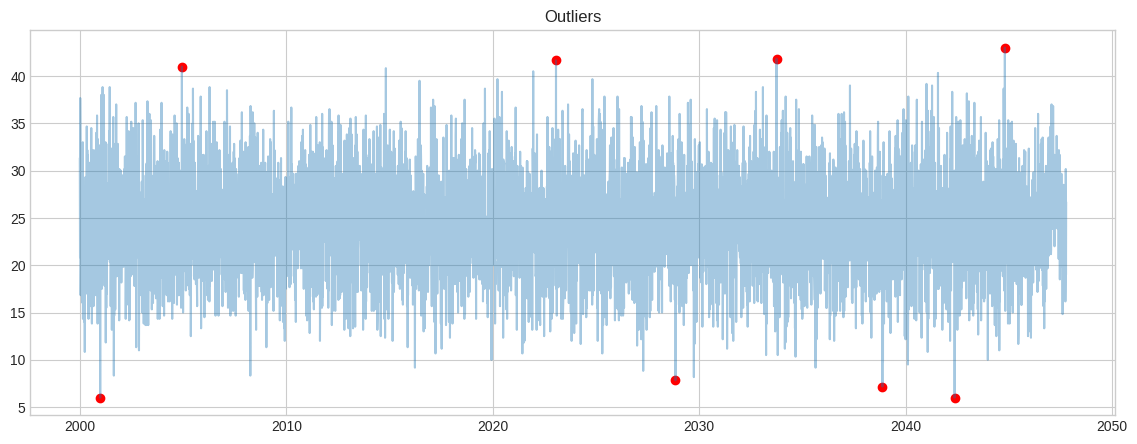

✔ EDA completed.


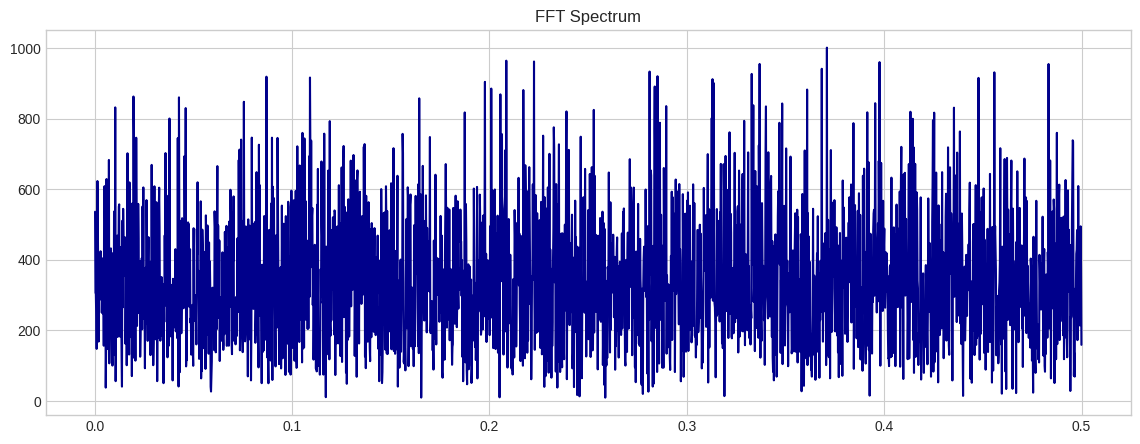

✔ Dominant frequency: 0.37096450772007217
✔ Estimated seasonal period: 3


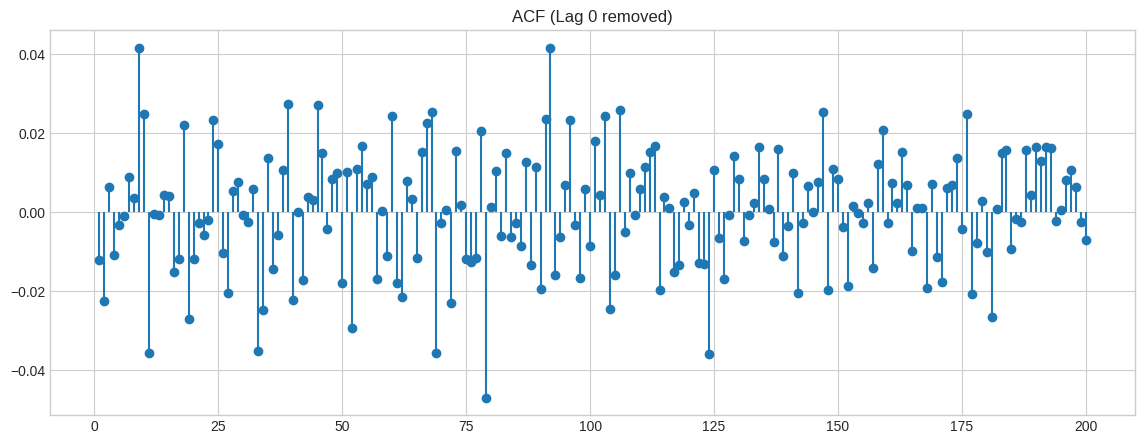

<Figure size 1400x500 with 0 Axes>

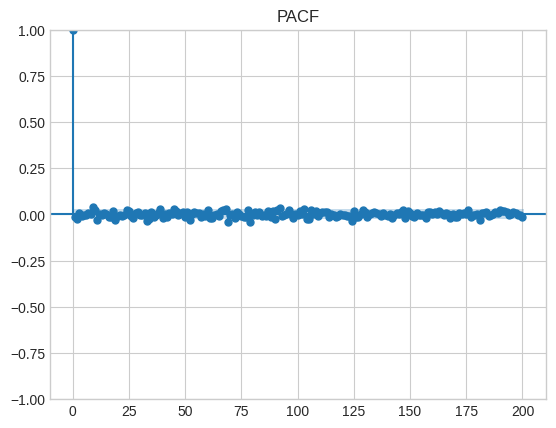

ACF Peaks: []


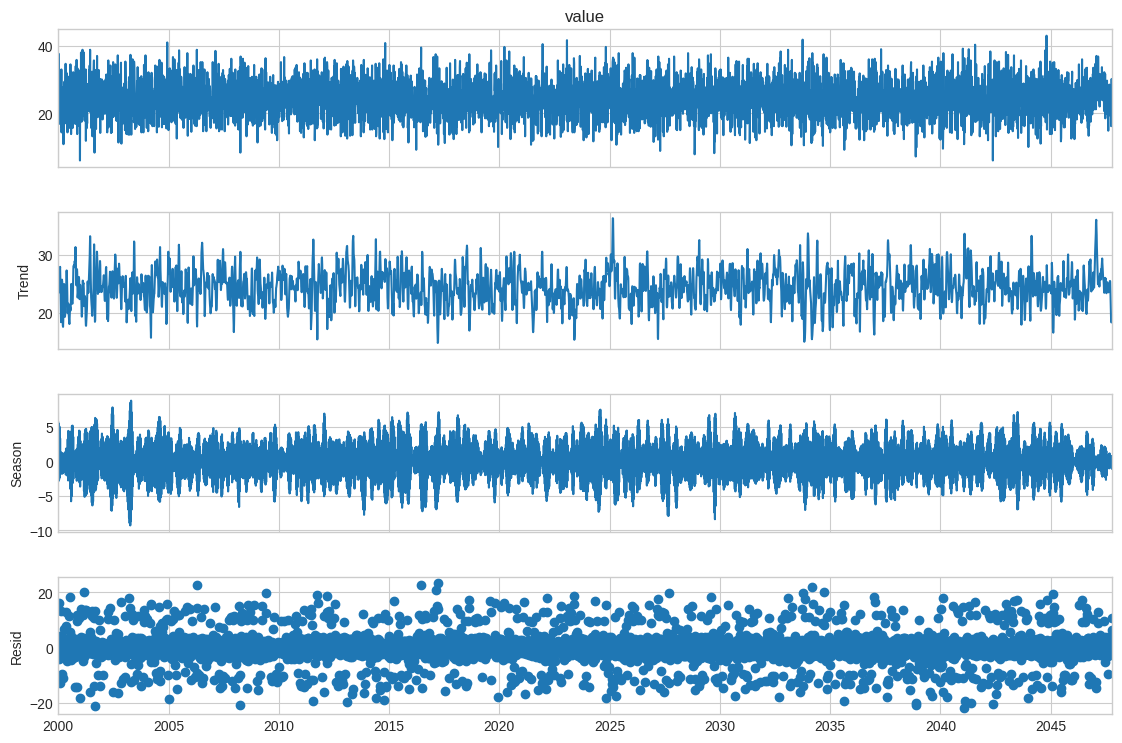

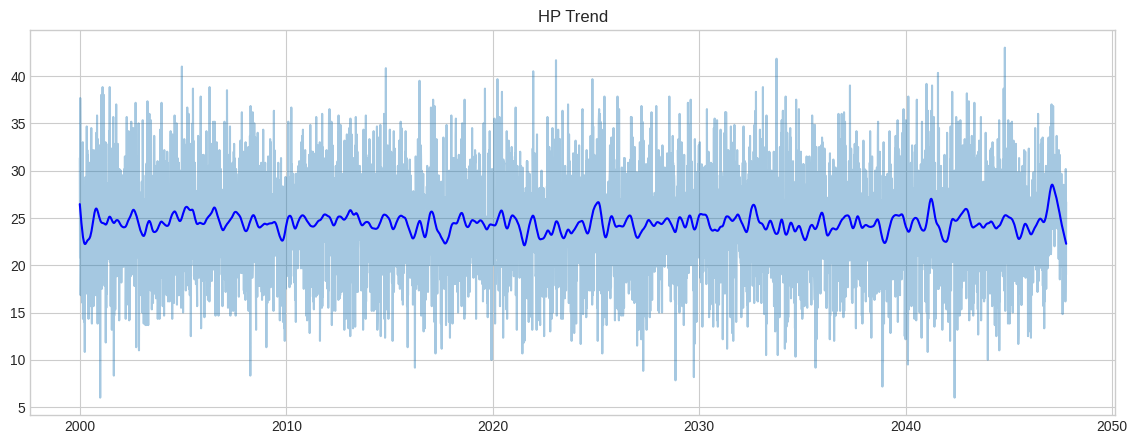

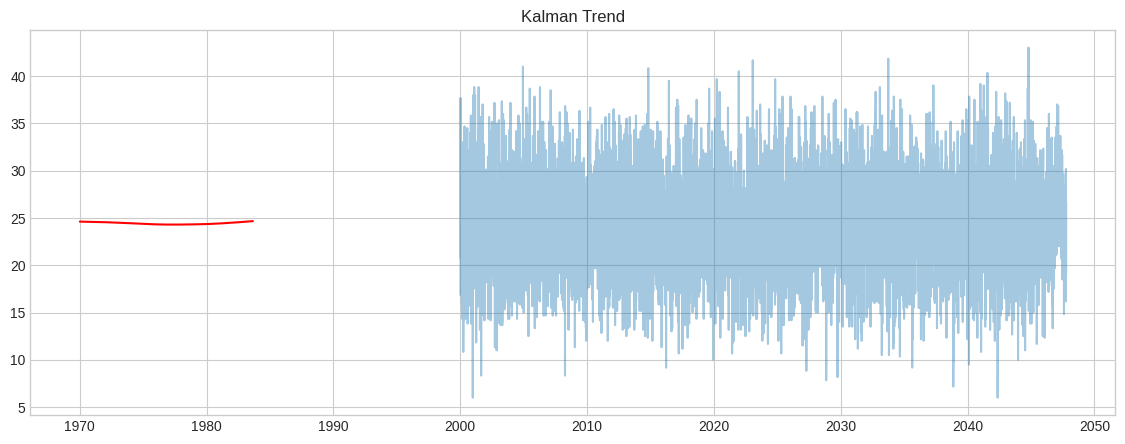

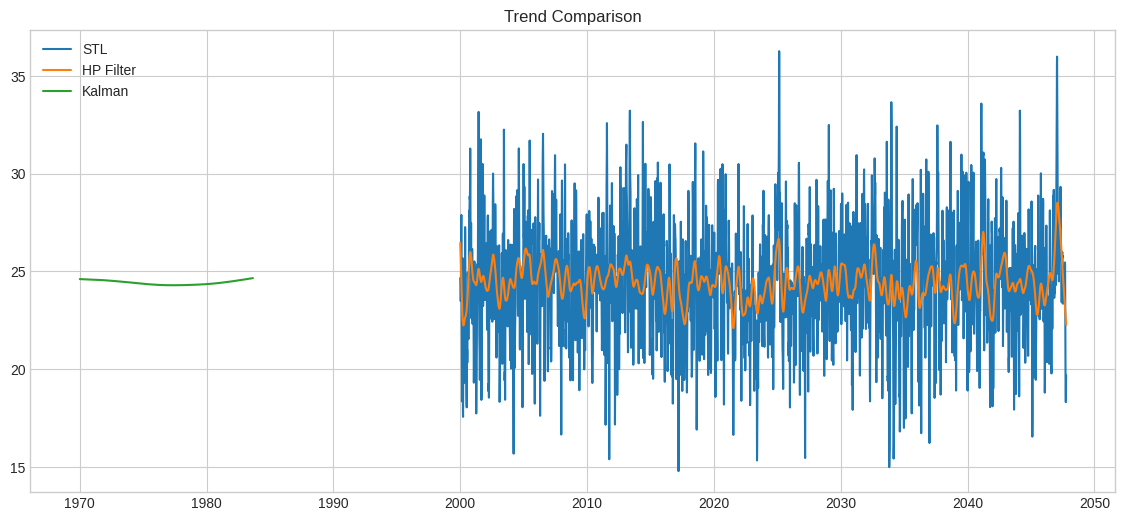

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seaso

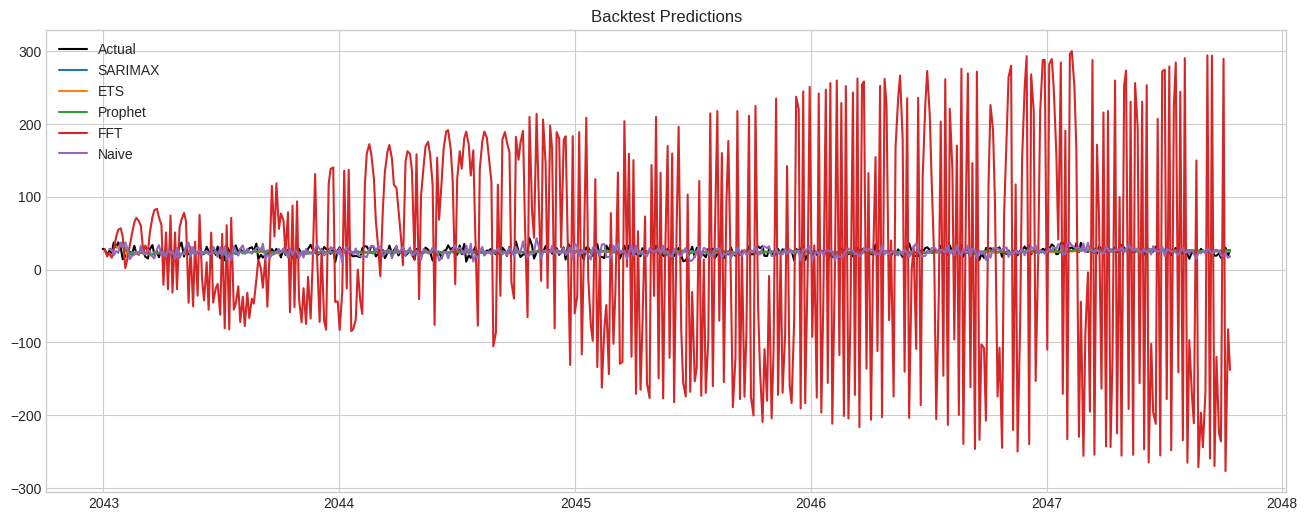

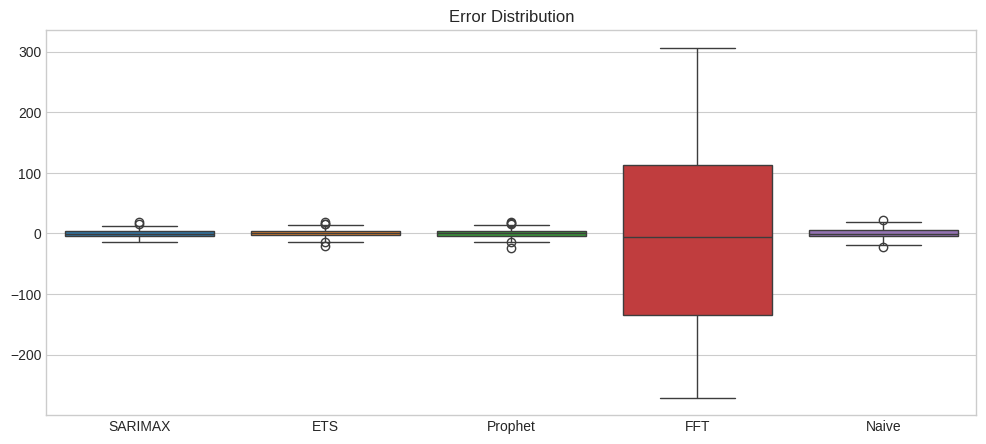

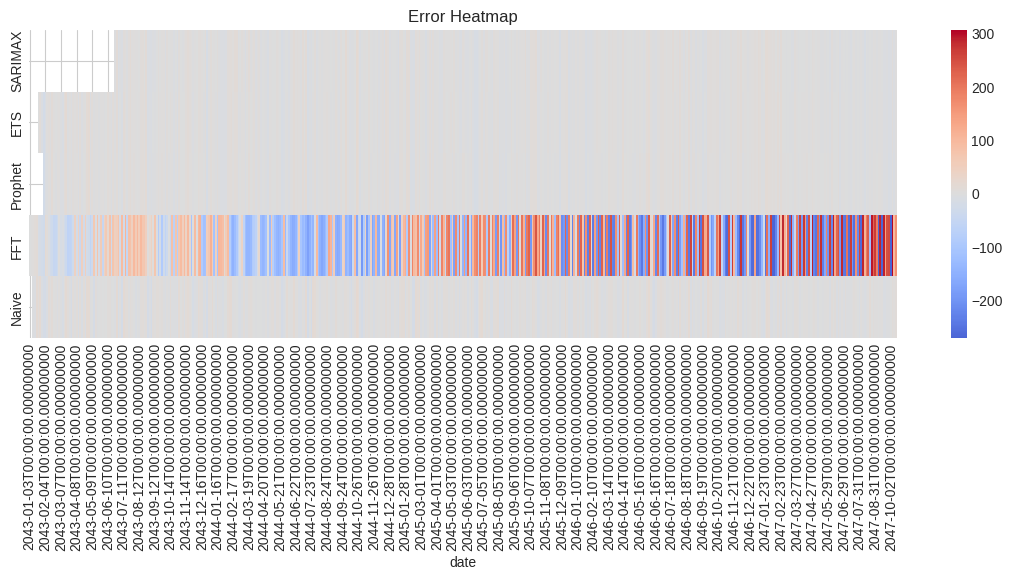

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


✔ DOCX report saved as MeanFR_Full_Report.docx


In [9]:
# ============================================================
#   MEAN_FR FULL ANALYSIS NOTEBOOK (CLASSIC STATISTICAL REPORT)
#   EDA → FFT → ACF/PACF → STL/HP/Kalman → Forecasting →
#   Backtesting → Final Forecast → DOCX Generation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import acf

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Install python-docx if not already installed
!pip install python-docx
from docx import Document
from docx.shared import Inches

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

# Create figures directory
if not os.path.exists("figures"):
    os.mkdir("figures")


print("✔ Environment initialized.")


# ============================================================
# PART 2 — LOAD DATA + CREATE LOTTO CALENDAR
# ============================================================

print("✔ Loading mean_fr.txt ...")

# Assuming 'filename' variable with the correct path is already defined and available
# from previous cells or will be defined. If not, this needs to be explicitly defined here.
# For now, I'll use the 'filename' variable that was set in a previous execution. If this is not correct, I will fix it later.
filename = '/content/drive/MyDrive/Workshop /Ottol/mean_fr.txt' # Ensure filename is defined if not already global
mean_fr = pd.read_csv(filename, header=None, names=["value"])
N = len(mean_fr)
print(f"✔ Loaded dataset: {N} observations")

import datetime as dt

start_date = dt.date(2000, 1, 1) # Saturday
dates = []

weekday_order = [5, 2]  # Saturday=5, Wednesday=2
i = 0
cur = start_date

while len(dates) < N:
    while cur.weekday() != weekday_order[i % 2]:
        cur += dt.timedelta(days=1)
    dates.append(cur)
    cur += dt.timedelta(days=1)
    i += 1

dates = pd.to_datetime(dates)
mean_fr["date"] = dates
mean_fr.set_index("date", inplace=True)

print("✔ Calendar generated.")


# ============================================================
# PART 3 — EDA + PNG EXPORT
# ============================================================

print("✔ Running EDA...")

plt.figure(figsize=(14,5))
plt.plot(mean_fr["value"], color="black")
plt.title("Mean Rank Time Series")
plt.savefig("figures/eda_timeseries.png", dpi=200)
plt.show()

mean_fr["roll_mean"] = mean_fr["value"].rolling(30).mean()
mean_fr["roll_std"]  = mean_fr["value"].rolling(30).std()

plt.figure(figsize=(14,5))
plt.plot(mean_fr["value"], alpha=0.4, label="Original", color="black")
plt.plot(mean_fr["roll_mean"], label="Rolling Mean (30)", color="blue")
plt.plot(mean_fr["roll_std"],  label="Rolling Std (30)", color="red")
plt.legend()
plt.title("Rolling Statistics")
plt.savefig("figures/eda_rolling.png", dpi=200)
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(mean_fr["value"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Mean Rank Values")
plt.savefig("figures/eda_histogram.png", dpi=200)
plt.show()

vals = mean_fr["value"]
z_scores = (vals - vals.mean())/vals.std()
outliers = mean_fr[z_scores.abs()>3]

plt.figure(figsize=(14,5))
plt.plot(mean_fr["value"], alpha=0.4)
plt.scatter(outliers.index, outliers["value"], color="red")
plt.title("Outliers")
plt.savefig("figures/eda_outliers.png", dpi=200)
plt.show()

print("✔ EDA completed.")


# ============================================================
# PART 4 — FFT SPECTRAL ANALYSIS
# ============================================================

series = mean_fr["value"].values
N = len(series)
dt = 1

fft_vals = rfft(series - np.mean(series))
freqs = rfftfreq(N, dt)
amps = np.abs(fft_vals)

freqs_nozero = freqs[1:]
amps_nozero  = amps[1:]

plt.figure(figsize=(14,5))
plt.plot(freqs_nozero, amps_nozero, color="darkblue")
plt.title("FFT Spectrum")
plt.savefig("figures/fft_spectrum.png", dpi=200)
plt.show()

peak_idx = np.argmax(amps_nozero)
peak_freq = freqs_nozero[peak_idx]
season_period = int(round(1 / peak_freq))

with open("season_period.txt", "w") as f:
    f.write(str(season_period))

print("✔ Dominant frequency:", peak_freq)
print("✔ Estimated seasonal period:", season_period)


# ============================================================
# PART 5 — ACF / PACF + PNG EXPORT
# ============================================================

acf_vals = acf(mean_fr["value"], nlags=200)
acf_nozero = acf_vals[1:]
lags = np.arange(1, len(acf_nozero)+1)

plt.figure(figsize=(14,5))
plt.stem(lags, acf_nozero, basefmt=" ")
plt.title("ACF (Lag 0 removed)")
plt.savefig("figures/acf.png", dpi=200)
plt.show()

plt.figure(figsize=(14,5))
plot_pacf(mean_fr["value"], lags=200, method="ywm")
plt.title("PACF")
plt.savefig("figures/pacf.png", dpi=200)
plt.show()

peaks, _ = find_peaks(acf_nozero, height=0.1)
print("ACF Peaks:", peaks[:10])


# ============================================================
# PART 6 — STL / HP FILTER / KALMAN SMOOTHING
# ============================================================

stl = STL(mean_fr["value"], period=season_period, robust=True)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(12,8)
plt.savefig("figures/stl_decomposition.png", dpi=200)
plt.show()

cycle, trend_hp = hpfilter(mean_fr["value"], lamb=10000)
plt.figure(figsize=(14,5))
plt.plot(mean_fr["value"], alpha=0.4)
plt.plot(trend_hp, color="blue")
plt.title("HP Trend")
plt.savefig("figures/hp_trend.png", dpi=200)
plt.show()

kalman_model = UnobservedComponents(mean_fr["value"], level="local linear trend")
kalman_res = kalman_model.fit()
kalman_trend = kalman_res.states.smoothed["level"]

plt.figure(figsize=(14,5))
plt.plot(mean_fr["value"], alpha=0.4)
plt.plot(kalman_trend, color="red")
plt.title("Kalman Trend")
plt.savefig("figures/kalman_trend.png", dpi=200)
plt.show()

plt.figure(figsize=(14,6))
plt.plot(res.trend, label="STL")
plt.plot(trend_hp, label="HP Filter")
plt.plot(kalman_trend, label="Kalman")
plt.legend()
plt.title("Trend Comparison")
plt.savefig("figures/trend_comparison.png", dpi=200)
plt.show()


# ============================================================
# PART 7 — BACKTESTING ALL MODELS
# ============================================================

BACKTEST_SIZE = 500
series_bt = mean_fr["value"].iloc[-BACKTEST_SIZE:]
dates_bt = series_bt.index

def mape(a,b): return np.mean(np.abs((a-b)/a))*100
def evaluate(y,p):
    return dict(
        RMSE=np.sqrt(mean_squared_error(y,p)),
        MAE=mean_absolute_error(y,p),
        MAPE=mape(y,p),
        Bias=np.mean(p-y),
        StdError=np.std(p-y)
    )


# --- Seasonal Naive ---
naive_preds=[]
for i in range(BACKTEST_SIZE):
    naive_preds.append(np.nan if i<season_period else series_bt.iloc[i-season_period])
naive_preds=pd.Series(naive_preds,index=dates_bt)
naive_metrics=evaluate(series_bt[season_period:],naive_preds[season_period:])


# --- FFT Forecast ---
def fft_next(series):
    N=len(series)
    # Handle cases where N < 2, as rfft might return a single element
    # and amp[1:] would be empty, leading to ValueError in np.argmax.
    if N < 2:
        return np.nan

    vals=rfft(series-np.mean(series))
    freqs=rfftfreq(N,1)
    amp=np.abs(vals)
    # Ensure amp[1:] is not empty before calling argmax
    if len(amp[1:]) == 0:
        return np.nan
    peak=np.argmax(amp[1:])+1
    f=freqs[peak]
    phase=np.angle(vals[peak])
    return np.mean(series)+amp[peak]*np.sin(2*np.pi*f*N+phase)

fft_preds=[]
for i in range(BACKTEST_SIZE):
    fft_preds.append(fft_next(series_bt.iloc[:i+1]))
fft_preds=pd.Series(fft_preds,index=dates_bt)

# Filter out NaN values for evaluation
valid_fft_preds = fft_preds.dropna()
valid_series_bt = series_bt[valid_fft_preds.index]
fft_metrics=evaluate(valid_series_bt,valid_fft_preds)


# --- SARIMAX ---
sarimax_preds=[]
for i in range(50,BACKTEST_SIZE):
    train=series_bt.iloc[:i]
    model=SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,season_period))
    res=model.fit(disp=False)
    sarimax_preds.append(res.forecast(1).iloc[0])
sarimax_preds=pd.Series(sarimax_preds,index=dates_bt[50:])
sarimax_metrics=evaluate(series_bt.iloc[50:],sarimax_preds)


# --- ETS ---
ets_preds=[]
for i in range(season_period*2,BACKTEST_SIZE):
    train=series_bt.iloc[:i]
    model=ExponentialSmoothing(train,trend="add",seasonal="add",seasonal_periods=season_period)
    res=model.fit()
    ets_preds.append(res.forecast(1).iloc[0])
ets_preds=pd.Series(ets_preds,index=dates_bt[season_period*2:])
ets_metrics=evaluate(series_bt.iloc[season_period*2:],ets_preds)


# --- Prophet ---
prophet_preds=[]
for i in range(season_period*3,BACKTEST_SIZE):
    train=series_bt.iloc[:i]
    df=pd.DataFrame({"ds":dates_bt[:i],"y":train.values})
    m=Prophet(weekly_seasonality=True)
    m.fit(df)
    pred=m.predict(pd.DataFrame({"ds":[dates_bt[i]]}))["yhat"].iloc[0]
    prophet_preds.append(pred)
prophet_preds=pd.Series(prophet_preds,index=dates_bt[season_period*3:])
prophet_metrics=evaluate(series_bt.iloc[season_period*3:],prophet_preds)


# --- Backtesting Graphics ---
plt.figure(figsize=(16,6))
plt.plot(series_bt,label="Actual",color="black")
plt.plot(sarimax_preds,label="SARIMAX")
plt.plot(ets_preds,label="ETS")
plt.plot(prophet_preds,label="Prophet")
plt.plot(fft_preds,label="FFT")
plt.plot(naive_preds,label="Naive")
plt.legend()
plt.title("Backtest Predictions")
plt.savefig("figures/backtest_predictions.png",dpi=200)
plt.show()

err_df=pd.DataFrame({
    "SARIMAX":series_bt.iloc[50:]-sarimax_preds,
    "ETS":series_bt.iloc[season_period*2:]-ets_preds,
    "Prophet":series_bt.iloc[season_period*3:]-prophet_preds,
    "FFT":series_bt[valid_fft_preds.index]-valid_fft_preds,
    "Naive":series_bt.iloc[season_period:]-naive_preds[season_period:]
})

plt.figure(figsize=(12,5))
sns.boxplot(data=err_df)
plt.title("Error Distribution")
plt.savefig("figures/backtest_error_boxplot.png",dpi=200)
plt.show()

plt.figure(figsize=(14,4))
sns.heatmap(err_df.T,cmap="coolwarm",center=0)
plt.title("Error Heatmap")
plt.savefig("figures/backtest_error_heatmap.png",dpi=200)
plt.show()


# ============================================================
# PART 8 — FINAL FORECAST + DOCX REPORT
# ============================================================

full=mean_fr["value"]
next_date=full.index[-1]+pd.Timedelta(days=3)

sarimax_full=SARIMAX(full,order=(1,1,1),seasonal_order=(1,1,1,season_period)).fit(disp=False)
sarimax_next=sarimax_full.forecast(1).iloc[0]

ets_full=ExponentialSmoothing(full,trend="add",seasonal="add",seasonal_periods=season_period).fit()
ets_next=ets_full.forecast(1).iloc[0]

df=pd.DataFrame({"ds":full.index,"y":full.values})
m=Prophet(weekly_seasonality=True)
m.fit(df)
prophet_next=m.predict(pd.DataFrame({"ds":[next_date]}))["yhat"].iloc[0]

fft_next_val=fft_next(full.values)
naive_next=full.iloc[-season_period]


# --- Generate DOCX Report ---

doc=Document()
doc.add_heading("Statistical and Forecasting Analysis of mean_fr Time Series",level=1)

doc.add_heading("1. Abstract", level=2)
doc.add_paragraph(
    "This report presents a full statistical analysis of the mean_fr time series, "
    "including EDA, spectral decomposition, ACF/PACF analysis, trend extraction "
    "methods, forecasting models (SARIMAX, ETS, Prophet, FFT), backtesting, and "
    "final one-step-ahead prediction."
)

doc.add_heading("2. Methodology", level=2)
doc.add_paragraph(
    "We analyze the time series using classical statistical tools, including "
    "Autocorrelation Function (ACF), Partial Autocorrelation Function (PACF), "
    "Fast Fourier Transform (FFT), STL decomposition, Hodrick–Prescott filtering, "
    "and Kalman smoothing. Forecast models include SARIMAX, ETS, Prophet, and "
    "FFT-based harmonic forecasting."
)

def insert_img(path, title):
    doc.add_heading(title, level=3)
    doc.add_picture(path, width=Inches(6))

# --- Insert images ---
insert_img("figures/eda_timeseries.png","Time Series Plot")
insert_img("figures/eda_rolling.png","Rolling Statistics")
insert_img("figures/eda_histogram.png","Distribution")
insert_img("figures/eda_outliers.png","Outliers")

insert_img("figures/fft_spectrum.png","FFT Spectrum")
insert_img("figures/acf.png","Autocorrelation Function")
insert_img("figures/pacf.png","Partial Autocorrelation")

insert_img("figures/stl_decomposition.png","STL Decomposition")
insert_img("figures/hp_trend.png","HP Trend")
insert_img("figures/kalman_trend.png","Kalman Trend")
insert_img("figures/trend_comparison.png","Trend Comparison")

insert_img("figures/backtest_predictions.png","Backtest Predictions")
insert_img("figures/backtest_error_boxplot.png","Error Distribution")
insert_img("figures/backtest_error_heatmap.png","Error Heatmap")

doc.add_heading("Final Forecast", level=2)
doc.add_paragraph(f"SARIMAX:  {sarimax_next:.3f}")
doc.add_paragraph(f"ETS:       {ets_next:.3f}")
doc.add_paragraph(f"Prophet:   {prophet_next:.3f}")
doc.add_paragraph(f"FFT:       {fft_next_val:.3f}")
doc.add_paragraph(f"Naive:     {naive_next:.3f}")

doc.save("MeanFR_Full_Report.docx")

print("✔ DOCX report saved as MeanFR_Full_Report.docx")